<a href="https://colab.research.google.com/github/Kmjng/BodyFat-Predict/blob/main/BodyFat_%ED%86%B5%EA%B3%84%EB%B6%84%EC%84%9D_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

In [35]:
file = r'/content/drive/MyDrive/Colab Notebooks/중간프로젝트 분석/Dataset.csv'

df = pd.read_csv(file)

In [ ]:
df.columns

Index(['Unnamed: 0', 'BodyFat', 'Original', 'Sex', 'Age', 'Weight', 'Height',
       'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps',
       'Forearm', 'Wrist', 'BMI', 'AC_ratio', 'HT_ratio', 'WHtR', 'WWI',
       'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  177 non-null    int64  
 1   BodyFat     177 non-null    float64
 2   Original    177 non-null    object 
 3   Sex         177 non-null    object 
 4   Age         177 non-null    int64  
 5   Weight      177 non-null    float64
 6   Height      177 non-null    float64
 7   Neck        177 non-null    float64
 8   Chest       177 non-null    float64
 9   Abdomen     177 non-null    float64
 10  Hip         177 non-null    float64
 11  Thigh       177 non-null    float64
 12  Knee        177 non-null    float64
 13  Ankle       177 non-null    float64
 14  Biceps      177 non-null    float64
 15  Forearm     177 non-null    float64
 16  Wrist       177 non-null    float64
 17  BMI         177 non-null    float64
 18  AC_ratio    177 non-null    float64
 19  HT_ratio    177 non-null    f

> (1) 가설 검정

In [36]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 독립 변수와 종속 변수 설정
X = df.drop(['Unnamed: 0','Original','Sex','Age','AC_ratio','HT_ratio','WHtR','WWI','Forearm','BMI','Class'], axis = 1)
y = df['BodyFat']

# 상수항 추가
X = sm.add_constant(X)
# 선형 회귀 모델 적합
#model = sm.Logit(y, X)
# 선형 회귀 모델 적합
model = sm.OLS(y, X)
result = model.fit()

# 회귀 분석 결과 출력
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                BodyFat   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.598e+26
Date:                Sun, 01 Sep 2024   Prob (F-statistic):               0.00
Time:                        12:10:32   Log-Likelihood:                 4704.5
No. Observations:                 177   AIC:                            -9383.
Df Residuals:                     164   BIC:                            -9342.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.146e-13   3.49e-12      0.033      0.9

> (3) 상관관계 (피어슨)

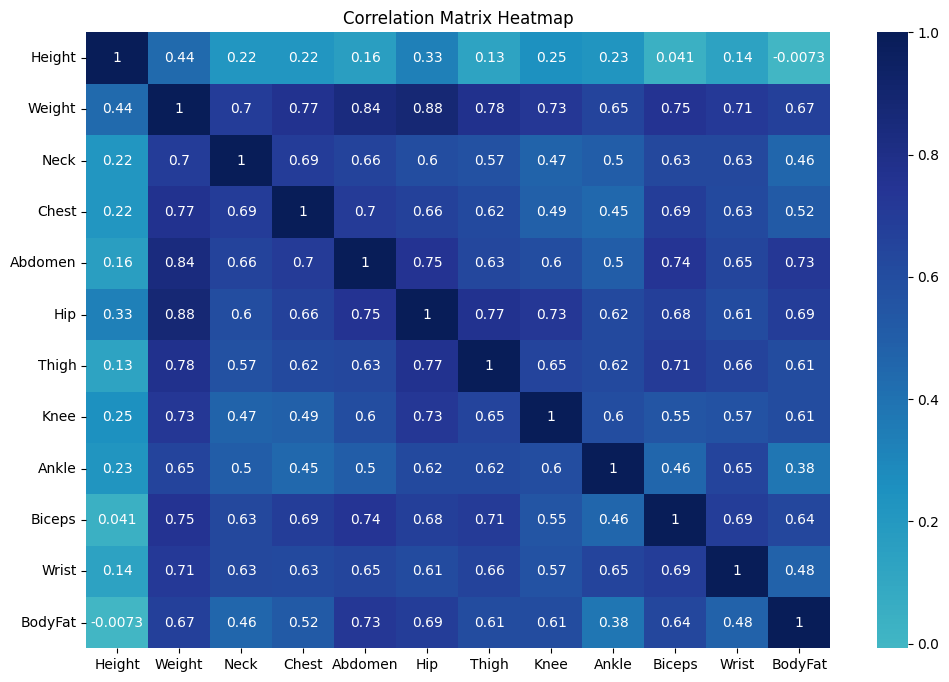

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(file)
df = df[['Height','Weight','Neck','Chest','Abdomen','Hip','Thigh','Knee','Ankle','Biceps','Wrist','BodyFat']]
X = df.drop('BodyFat', axis = 1)
y = df.BodyFat
# X와 y를 하나의 데이터프레임으로 합침
data = pd.concat([X, y], axis=1)

# 상관관계 행렬 계산
corr_matrix = data.corr()

# 히트맵 생성
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

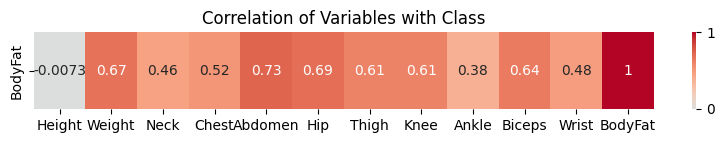

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 특정 변수 'Class'와 나머지 변수들 간의 상관관계만 계산
correlation_with_class = df.corr()['BodyFat']

# 히트맵으로 시각화
plt.figure(figsize=(10, 1))
sns.heatmap(correlation_with_class.to_frame().T, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Variables with Class')
plt.xticks(rotation = 0)
plt.show()

> (3) 다중공선성 확인

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

file = r'/content/drive/MyDrive/Colab Notebooks/중간프로젝트 분석/Dataset.csv'
df = pd.read_csv(file)
df = df.drop(['Unnamed: 0','Original','Sex','Age','AC_ratio','HT_ratio','WHtR','WWI','Forearm','BMI','Class','BodyFat'], axis = 1)

# 상수항 추가
X = add_constant(df)
# VIF 계산
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

print(vif)

     VIF Factor features
0   4122.763731    const
1     15.255002   Weight
2      2.155574   Height
3      2.405360     Neck
4      3.074742    Chest
5      4.679040  Abdomen
6      5.222439      Hip
7      3.693424    Thigh
8      2.535508     Knee
9      2.342264    Ankle
10     3.617144   Biceps
11     2.905064    Wrist


> (4) 정규성 확인

In [ ]:
import pandas as pd
import scipy.stats as stats

# 데이터프레임 (177개의 행과 11개의 칼럼)


# 결과를 저장할 빈 리스트 생성
results_list = []

# 각 칼럼에 대해 Kolmogorov-Smirnov 검정 수행
for col in df.columns:
    stat, p_value = stats.shapiro(df[col])
    normality = 'Y' if p_value > 0.05 else 'N'

    # 결과를 리스트에 추가
    results_list.append({
        'Column': col,
        'Statistic': round(stat,2),
        'p-value': p_value,
        'Normality': normality
    })

# 리스트를 데이터프레임으로 변환
results = pd.DataFrame(results_list)

# 결과 출력
print(results)

     Column  Statistic       p-value Normality
0    Weight       0.98  1.615179e-02         N
1    Height       0.98  3.815132e-02         N
2      Neck       0.99  7.423621e-02         Y
3     Chest       0.99  2.290020e-01         Y
4   Abdomen       0.93  7.125452e-08         N
5       Hip       0.99  1.519746e-01         Y
6     Thigh       0.99  5.309845e-01         Y
7      Knee       0.96  7.769214e-05         N
8     Ankle       0.96  1.387016e-04         N
9    Biceps       0.98  4.139518e-02         N
10    Wrist       0.98  8.588947e-03         N
